<a href="https://colab.research.google.com/github/alwacoder21/Datascience_240401020052/blob/main/Tugas_UTS_Rizal_Alwa_Porniawan_240401020052.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello, Data Science!
Selamat datang di mata kuliah Pengantar Data Science!
Nama : Rizal ALwa Porniawan
Angkatan: 2024
IPK : 3.75
Aktif : True

Tools Data Science yang akan kita pelajari:
 1. Python
 2. Google Colab
 3. Jupyter Notebook
 4. GitHub
Hai! Saya Budi Santoso dari Informatika, angkatan 2024.
10
3.14
[20, 'Python']
Budi Santoso
0
Dataset bersih:


,kota,luas_m2,harga_juta,kamar,kondisi,tahun_bangun
0,Jakarta,100.00,500.00,2.0,baru,2020
1,Bandung,120.00,500.00,3.0,lama,2015
2,Jakarta,120.00,450.00,2.0,baru,2018
3,Surabaya,146.25,643.75,2.0,baru,2022



=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762


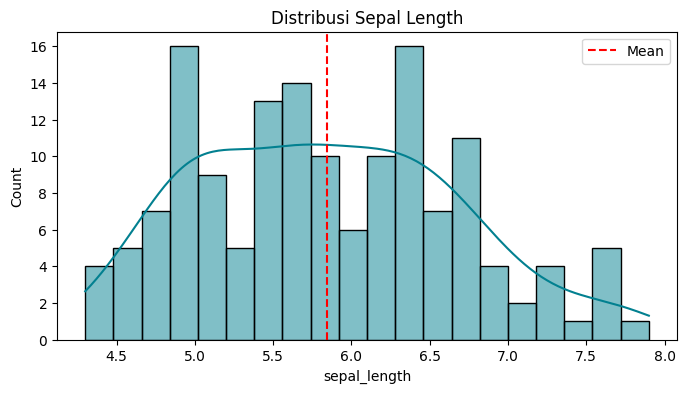

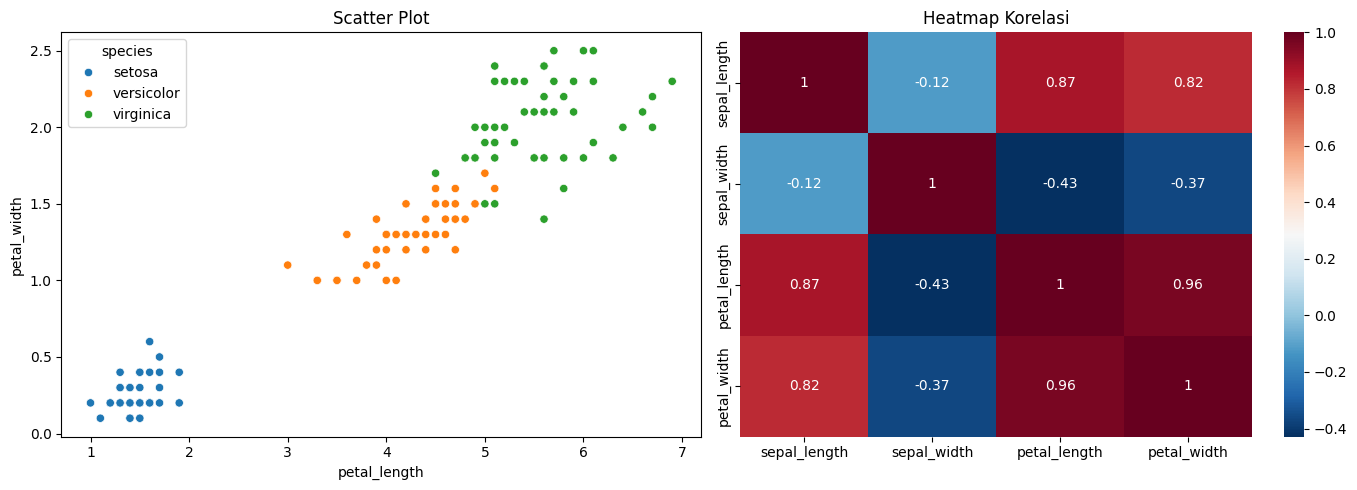

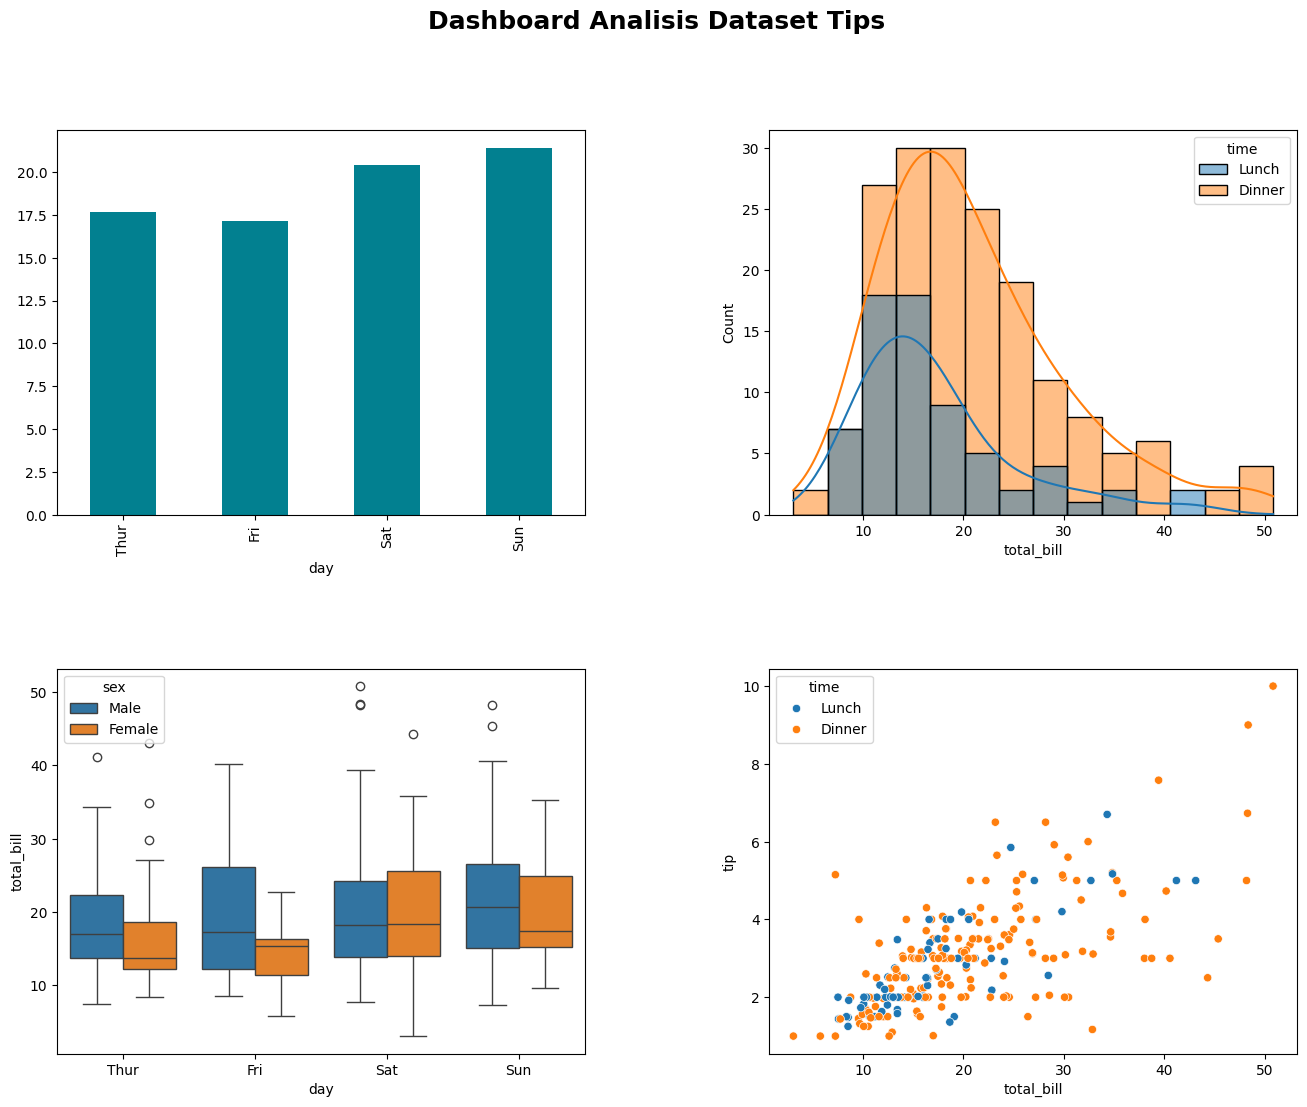

R2 Score: 0.9740


In [23]:

#Ujian Tengah Semester
#Rizal Alwa Porniawan
#240401020052
#PJJ Informatika Unsia




# ================================================
# PERTEMUAN 1: Notebook Pertama Data Science
# ================================================
# SEL 1: Output sederhana
print("Hello, Data Science!")
print("Selamat datang di mata kuliah Pengantar Data Science!")
# SEL 2: Variabel dan tipe data dasar
nama = "Rizal ALwa Porniawan" # String
angkatan = 2024 # Integer
ipk = 3.75 # Float
aktif = True # Boolean
print(f"Nama : {nama}")
print(f"Angkatan: {angkatan}")
print(f"IPK : {ipk}")
print(f"Aktif : {aktif}")
# SEL 3: List dan perulangan
tools = ["Python", "Google Colab", "Jupyter Notebook", "GitHub"]
print("\nTools Data Science yang akan kita pelajari:")
for i, tool in enumerate(tools, 1):
    print(f" {i}. {tool}")
# SEL 4: Fungsi sederhana
def perkenalan(nama, prodi, angkatan):
    """Fungsi untuk menampilkan perkenalan mahasiswa."""
    return f"Hai! Saya {nama} dari {prodi}, angkatan {angkatan}."
hasil = perkenalan("Budi Santoso", "Informatika", 2024)
print(hasil)

# ================================================
# Pertemuan 2
# ================================================
data = [10, 20, 'Python', True, 3.14]
print(data[0])
print(data[-1])
print(data[1:3])
data.append(99)
data.insert(1, 55)
data.remove(20)

mahasiswa = {'nama': 'Budi Santoso', 'nim': '2024001', 'prodi': 'Informatika', 'ipk': 3.85}
print(mahasiswa['nama'])
print(mahasiswa.get('usia', 0))
mahasiswa['angkatan'] = 2024
del mahasiswa['nim']

import numpy as np
a1D = np.array([1, 2, 3, 4, 5])
a2D = np.array([[1,2,3],[4,5,6]])

# ================================================
# Pertemuan 3
# ================================================
import pandas as pd, numpy as np
dummy_data = {
    'kota': [' jakarta', 'Bandung ', 'jakarta', 'Surabaya'],
    'luas_m2': [100, 120, np.nan, 150],
    'harga_juta': [500, np.nan, 450, 700],
    'kamar': [2, 3, 2, np.nan],
    'kondisi': ['BARU', ' lama', 'Baru', 'baru'],
    'tahun_bangun': [2020, 2015, 2018, 2022]
}
pd.DataFrame(dummy_data).to_csv('housing_dirty.csv', index=False)

df_housing = pd.read_csv('housing_dirty.csv')
df_housing.drop_duplicates(inplace=True)
df_housing['kota'] = df_housing['kota'].str.strip().str.title()
df_housing['kondisi'] = df_housing['kondisi'].str.strip().str.lower()
df_housing['luas_m2'] = df_housing['luas_m2'].fillna(df_housing['luas_m2'].median())
df_housing['harga_juta'] = df_housing['harga_juta'].fillna(df_housing['harga_juta'].median())
df_housing['kamar'] = df_housing['kamar'].fillna(df_housing['kamar'].mode()[0])

for col in ['harga_juta', 'luas_m2', 'tahun_bangun']:
    Q1, Q3 = df_housing[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_housing[col] = df_housing[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

print('Dataset bersih:')
display(df_housing.head())

# ================================================
# Pertemuan 4
# ================================================
import matplotlib.pyplot as plt, seaborn as sns
df_iris = sns.load_dataset('iris')

for col_name in df_iris.select_dtypes(include='number').columns:
    col_data = df_iris[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean : {col_data.mean():.3f}')
    print(f' Median : {col_data.median():.3f}')
    print(f' Std Dev : {col_data.std():.3f}')

fig4, ax4 = plt.subplots(figsize=(8, 4))
sns.histplot(df_iris['sepal_length'], kde=True, color='#028090', bins=20, ax=ax4)
ax4.axvline(df_iris['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean")
ax4.set_title('Distribusi Sepal Length'); ax4.legend(); plt.show()

fig4b, axes4b = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_iris, x='petal_length', y='petal_width', hue='species', ax=axes4b[0])
axes4b[0].set_title('Scatter Plot')

corr_iris = df_iris.select_dtypes(include='number').corr()
sns.heatmap(corr_iris, annot=True, cmap='RdBu_r', ax=axes4b[1])
axes4b[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()

# ================================================
# Pertemuan 5
# ================================================
import matplotlib.gridspec as gridspec
df_tips = sns.load_dataset('tips')
fig5 = plt.figure(figsize=(16, 12))
fig5.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig5, hspace=0.4, wspace=0.35)
ax1, ax2, ax3, ax4 = fig5.add_subplot(gs[0,0]), fig5.add_subplot(gs[0,1]), fig5.add_subplot(gs[1,0]), fig5.add_subplot(gs[1,1])
df_tips.groupby('day', observed=True)['total_bill'].mean().plot(kind='bar', ax=ax1, color='#028090')
sns.histplot(data=df_tips, x='total_bill', hue='time', kde=True, ax=ax2)
sns.boxplot(data=df_tips, x='day', y='total_bill', hue='sex', ax=ax3)
sns.scatterplot(data=df_tips, x='total_bill', y='tip', hue='time', ax=ax4)
plt.show()

# ================================================
# Pertemuan 6
# ================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df_titanic = sns.load_dataset('titanic')[['pclass','sex','age','sibsp','parch','fare','embarked','survived']].copy()
df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())
df_titanic['embarked'] = df_titanic['embarked'].fillna(df_titanic['embarked'].mode()[0])
df_titanic = pd.get_dummies(df_titanic, columns=['sex', 'embarked'], drop_first=True, dtype=int)

# ================================================
# Pertemuan 7
# ================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42); n = 300
px = np.random.uniform(0, 20, n); edu_n = np.random.choice([0, 1, 2], n)
kota_n = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji_n = (3.0 + 2.2*px + 1.5*edu_n + np.where(kota_n=='Jakarta', 4.0, 0) + np.random.normal(0, 2, n))
df_reg = pd.DataFrame({'pengalaman':px, 'edu':edu_n, 'kota':kota_n, 'gaji':gaji_n})
df_reg = pd.get_dummies(df_reg, columns=['kota'], drop_first=True, dtype=int)

X_r = df_reg.drop('gaji', axis=1); y_r = df_reg['gaji']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
scaler_r = StandardScaler(); Xr_train_s = scaler_r.fit_transform(Xr_train); Xr_test_s = scaler_r.transform(Xr_test)
model_r = LinearRegression().fit(Xr_train_s, yr_train)
yr_pred = model_r.predict(Xr_test_s)
print(f'R2 Score: {r2_score(yr_test, yr_pred):.4f}')

#Kesimpulan :
#Berdasarkan rangkaian praktikum dan implementasi kode dari Pertemuan 1 sampai Pertemuan 7, dapat disimpulkan bahwa proses Data Science terdiri dari beberapa tahapan yang saling berkaitan, mulai dari pemrograman dasar, pengolahan data, visualisasi data, hingga pembangunan model machine learning.
#Pada Pertemuan 1, dipelajari dasar-dasar pemrograman Python seperti penggunaan variabel, tipe data, list, perulangan (looping), dan fungsi. Materi ini menjadi fondasi penting dalam pengembangan program untuk analisis data.
#Pada Pertemuan 2, dipelajari struktur data Python yang meliputi list, dictionary, serta penggunaan library NumPy untuk mengelola array dan melakukan komputasi numerik secara lebih efisien. Pemahaman struktur data sangat penting dalam pengelolaan dan manipulasi data dalam jumlah besar.
#Pada Pertemuan 3, dipelajari proses Data Cleaning menggunakan Pandas. Tahapan yang dilakukan meliputi penghapusan data duplikat, normalisasi data teks, penanganan missing values menggunakan median dan modus, serta penanganan outlier menggunakan metode Interquartile Range (IQR). Temuan utama dari tahap ini adalah kualitas data sangat memengaruhi hasil analisis sehingga data harus dibersihkan terlebih dahulu sebelum digunakan.
#Pada Pertemuan 4, dipelajari statistik deskriptif dan visualisasi data menggunakan Matplotlib dan Seaborn. Melalui histogram, scatter plot, dan heatmap korelasi pada dataset Iris, dapat diketahui distribusi data, hubungan antar variabel, serta pola yang terdapat dalam dataset. Visualisasi membantu memahami karakteristik data secara lebih mudah dan intuitif.
#Pada Pertemuan 5, dipelajari pembuatan dashboard analisis data menggunakan berbagai jenis grafik pada dataset Tips. Dashboard memungkinkan penyajian informasi yang lebih terstruktur sehingga memudahkan proses interpretasi dan pengambilan keputusan berdasarkan data.
#Pada Pertemuan 6, dipelajari tahap persiapan data untuk machine learning, termasuk penanganan missing values, encoding variabel kategorik menggunakan One-Hot Encoding, pembagian data menjadi data latih dan data uji (train-test split), serta normalisasi data menggunakan StandardScaler. Tahap ini menunjukkan bahwa kualitas preprocessing sangat berpengaruh terhadap performa model yang akan dibangun.
#Pada Pertemuan 7, dipelajari penerapan algoritma Linear Regression untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat tinggal. Model dievaluasi menggunakan metrik R² Score. Hasil yang diperoleh menunjukkan nilai R² yang tinggi, menandakan bahwa model mampu menjelaskan sebagian besar variasi data target dengan baik. Temuan utama dari tahap ini adalah pengalaman kerja, tingkat pendidikan, dan lokasi memiliki pengaruh terhadap besarnya gaji yang diterima.
#Secara keseluruhan, praktikum ini memberikan pemahaman menyeluruh mengenai alur kerja Data Science, mulai dari pengumpulan dan pembersihan data, eksplorasi dan visualisasi data, preprocessing, hingga pembangunan dan evaluasi model machine learning. Penguasaan tahapan-tahapan tersebut merupakan keterampilan dasar yang sangat penting dalam bidang Data Science dan analisis data modern.

